SIMPLE LINEAR REGRESSION
R² Score       : 0.0519
Accuracy (%)   : 5.19%
RMSE           : 23.8641


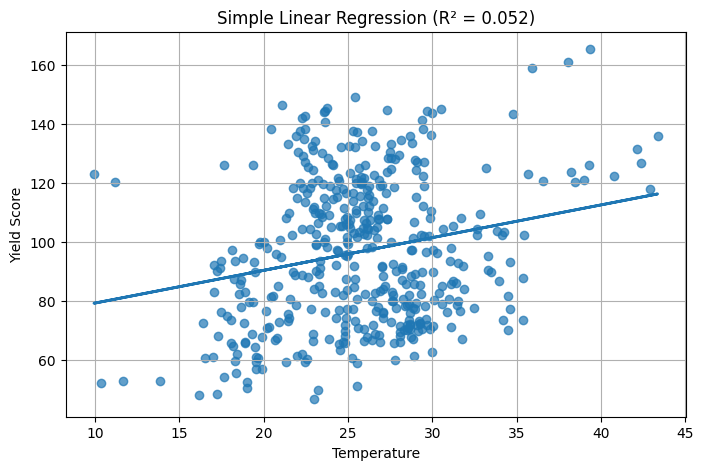

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('Crop_recommendation.csv')

np.random.seed(42)

df['yield_score'] = (
    0.5 * df['N'] +
    0.3 * df['P'] +
    0.2 * df['K'] +
    1.5 * df['temperature'] +
    0.1 * df['humidity'] +
    np.random.normal(0, 5, len(df))
)

X = df[['temperature']]
y = df['yield_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("=" * 50)
print("SIMPLE LINEAR REGRESSION")
print("=" * 50)
print(f"R² Score       : {r2:.4f}")
print(f"Accuracy (%)   : {accuracy:.2f}%")
print(f"RMSE           : {rmse:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.7)
plt.plot(X_test, y_pred, linewidth=2)

plt.xlabel("Temperature")
plt.ylabel("Yield Score")
plt.title(f"Simple Linear Regression (R² = {r2:.3f})")
plt.grid(True)
plt.show()

MULTIPLE LINEAR REGRESSION
R² Score       : 0.9596
Accuracy (%)   : 95.96%
RMSE           : 4.9279


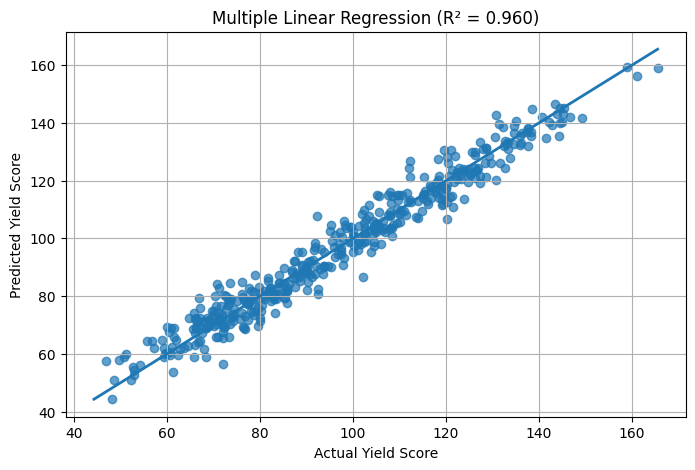

In [33]:
X = df[['N', 'P', 'K', 'temperature', 'humidity']]
y = df['yield_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("=" * 50)
print("MULTIPLE LINEAR REGRESSION")
print("=" * 50)
print(f"R² Score       : {r2:.4f}")
print(f"Accuracy (%)   : {accuracy:.2f}%")
print(f"RMSE           : {rmse:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("Actual Yield Score")
plt.ylabel("Predicted Yield Score")
plt.title(f"Multiple Linear Regression (R² = {r2:.3f})")
plt.grid(True)
plt.show()

In [36]:
import pickle
with open('simple_linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Simple Linear Regression model saved successfully.")


Simple Linear Regression model saved successfully.


In [37]:


with open('multiple_linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully as multiple_linear_regression_model.pkl")

Model saved successfully as multiple_linear_regression_model.pkl


In [39]:
import joblib

joblib.dump(model, 'simple_linear_regression_model.joblib')
print("Simple Linear Regression model saved successfully as simple_linear_regression_model.joblib")


Simple Linear Regression model saved successfully as simple_linear_regression_model.joblib


In [40]:
joblib.dump(model, 'multiple_linear_regression_model.joblib')
print("Multiple Linear Regression model saved successfully as multiple_linear_regression_model.joblib")

Multiple Linear Regression model saved successfully as multiple_linear_regression_model.joblib
